# 03 – Model 1: Presidio REGEX Pipeline
Rule-based PII detection using Microsoft Presidio Analyzer.


In [7]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from presidio_analyzer import Pattern, PatternRecognizer
from src.utils.io import load_json, load_jsonl
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

## Source Code Walkthrough

The Presidio pipeline is built from three source files. Below we display the key logic from each.

### custom_recognizers.py — Custom email & username detectors

Presidio has no built-in USERNAME recognizer, and its EMAIL_ADDRESS recognizer
misses many formats. We add two custom pattern-based recognizers:

In [8]:
# src/models/regex_presidio/custom_recognizers.py

class EmailRecognizer(PatternRecognizer):
    """Presidio's built-in EMAIL_ADDRESS misses many formats.
    Our regex catches standard user@domain.tld patterns."""
    PATTERNS = [
        Pattern("EMAIL_FULL", r"[a-zA-Z0-9_.+-]+@[a-zA-Z0-9-]+\.[a-zA-Z]{2,}", 0.95),
    ]
    CONTEXT = ["email", "e-mail", "mail", "contact", "reach"]

    def __init__(self):
        super().__init__(
            supported_entity="EMAIL_ADDRESS",
            patterns=self.PATTERNS, context=self.CONTEXT,
        )


class UsernameRecognizer(PatternRecognizer):
    """Matches @handle social-media usernames (e.g., @john_doe)."""
    PATTERNS = [
        Pattern("USERNAME_HANDLE", r"@[a-zA-Z0-9_]{2,30}\b", 0.85),
    ]
    CONTEXT = ["username", "handle", "account", "user"]

    def __init__(self):
        super().__init__(
            supported_entity="USERNAME",
            patterns=self.PATTERNS, context=self.CONTEXT,
        )

### predictor.py — Main prediction pipeline

Builds the Presidio analyzer, runs it on each record, maps entity types
to our unified schema, and converts character spans to BIO labels:


In [9]:
from utils.io import tokens_to_text_with_offsets, char_spans_to_bio
from models.regex_presidio.custom_recognizers import get_custom_recognizers
from presidio_analyzer.nlp_engine import NlpEngineProvider
from presidio_analyzer import AnalyzerEngine
import re

# src/models/regex_presidio/predictor.py

# Regex for emails — runs after Presidio to catch what the built-in misses
_EMAIL_RE = re.compile(r"[a-zA-Z0-9_.+-]+@[a-zA-Z0-9-]+\.[a-zA-Z]{2,}")

# Map Presidio's entity names → our unified 7-label schema
PRESIDIO_TO_UNIFIED = {
    "PERSON":        "PERSON",
    "EMAIL_ADDRESS": "EMAIL",
    "PHONE_NUMBER":  "PHONE",
    "LOCATION":      "ADDRESS",
    "URL":           "URL",
    "US_SSN":        "ID",
    "USERNAME":      "USERNAME",
    # ... + 15 more ID-type recognizers
}


def build_analyzer() -> AnalyzerEngine:
    """Create the Presidio engine with spaCy NLP + our custom recognizers."""
    provider = NlpEngineProvider(nlp_configuration={
        "nlp_engine_name": "spacy",
        "models": [{"lang_code": "en", "model_name": "en_core_web_lg"}],
    })
    analyzer = AnalyzerEngine(nlp_engine=provider.create_engine())
    for rec in get_custom_recognizers():       # EmailRecognizer, UsernameRecognizer
        analyzer.registry.add_recognizer(rec)
    return analyzer


def predict_record(record, analyzer, score_threshold=0.35):
    """Run Presidio on one record → return BIO labels aligned to its tokens."""
    tokens = record["tokens"]
    text, char_starts = tokens_to_text_with_offsets(tokens, ...)

    # Step 1: Run all Presidio recognizers
    results = analyzer.analyze(text=text, language="en",
                               score_threshold=score_threshold)

    # Step 2: Map Presidio entity types → unified schema
    spans = []
    for r in results:
        unified = PRESIDIO_TO_UNIFIED.get(r.entity_type)
        if unified:
            spans.append({"type": unified, "start": r.start, "end": r.end})

    # Step 3: Post-process — our email regex catches emails that Presidio
    #         classified as URL (it matches the domain part only)
    email_spans = [{"type": "EMAIL", "start": m.start(), "end": m.end()}
                   for m in _EMAIL_RE.finditer(text)]
    if email_spans:
        # Remove any Presidio spans that overlap our detected emails
        spans = [s for s in spans
                 if not any(s["start"] < e["end"] and s["end"] > e["start"]
                            for e in email_spans)]
        spans.extend(email_spans)

    # Step 4: Convert character spans → word-level BIO labels
    return char_spans_to_bio(tokens, char_starts, spans)

## Load pre-computed results

In [10]:
# Results pre-computed on cluster — load directly
results_path = Path('../outputs/results/regex_results.json')
results = load_json(results_path)
m = results['metrics']
print(f"Presidio — Precision: {m['precision']:.4f}  Recall: {m['recall']:.4f}  F1: {m['f1']:.4f}")
print(f"Latency: {m.get('latency_ms_per_record', '?'):.1f} ms / record")

Presidio — Precision: 0.5497  Recall: 0.3986  F1: 0.4621
Latency: 13.3 ms / record


## 2. Per-entity Scores

,entity,precision,recall,f1,support
4,PHONE,0.7131,0.7647,0.7380,221
3,PERSON,0.5328,0.4384,0.4810,4669
1,EMAIL,0.9446,0.3108,0.4678,1097
5,URL,0.6316,0.3582,0.4571,201
0,ADDRESS,0.4575,0.3168,0.3743,1528
6,USERNAME,0.9722,0.1902,0.3182,184
2,ID,0.2214,0.4143,0.2886,70


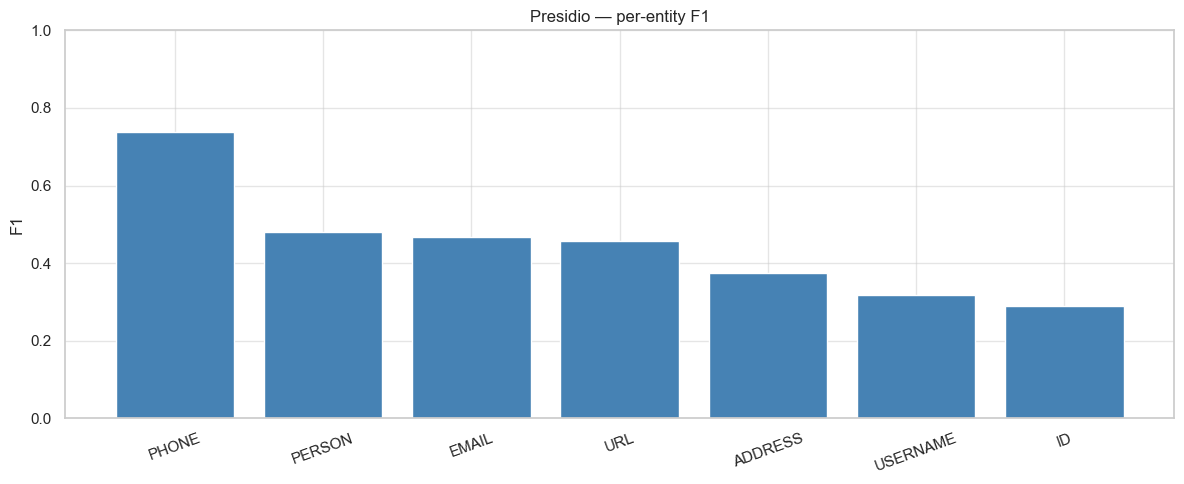

In [11]:
import pandas as pd
per = results['metrics'].get('per_entity', {})
rows = [{'entity': k, **v} for k, v in per.items()]
df = pd.DataFrame(rows).sort_values('f1', ascending=False)
display(df)

fig, ax = plt.subplots()
ax.bar(df['entity'], df['f1'], color='steelblue', edgecolor='white')
ax.set_title('Presidio — per-entity F1')
ax.set_ylim(0, 1)
ax.set_ylabel('F1')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('../outputs/results/presidio_per_entity_f1.png', dpi=150)
plt.show()

## 3. Error Analysis — Where Presidio fails

Presidio is rule-based with no learning capability. We categorize its errors to understand the limitations of the regex approach.

In [15]:
from IPython.display import display, HTML
from src.utils.io import tokens_to_text

test_records = load_jsonl('../data/processed/test.jsonl')
preds = results['predictions']

# Categorize all errors
false_positives = []
false_negatives = []
wrong_types = []

for rec, pred in zip(test_records, preds):
    gt = rec['labels']
    toks = rec['tokens']
    text = tokens_to_text(toks, rec.get('trailing_whitespace'))

    for i in range(min(len(gt), len(pred))):
        if gt[i].startswith('B-') and pred[i] == 'O':
            etype = gt[i][2:]
            j = i + 1
            while j < len(gt) and gt[j] == f'I-{etype}': j += 1
            false_negatives.append({
                'entity': ' '.join(toks[i:j]), 'type': etype,
                'text': text[:200], 'source': rec.get('source')
            })
        elif pred[i].startswith('B-') and gt[i] == 'O':
            etype = pred[i][2:]
            j = i + 1
            while j < len(pred) and pred[j] == f'I-{etype}': j += 1
            false_positives.append({
                'entity': ' '.join(toks[i:j]), 'type': etype,
                'text': text[:200], 'source': rec.get('source')
            })
        elif gt[i].startswith('B-') and pred[i].startswith('B-') and gt[i] != pred[i]:
            wrong_types.append({
                'entity': toks[i], 'gt_type': gt[i][2:], 'pred_type': pred[i][2:],
                'text': text[:200], 'source': rec.get('source')
            })

print(f"Error breakdown across {len(test_records):,} test records:")
print(f"  False negatives (missed PII):     {len(false_negatives)}")
print(f"  False positives:                   {len(false_positives)}")
print(f"  Wrong entity type:                 {len(wrong_types)}")

Error breakdown across 4,710 test records:
  False negatives (missed PII):     3812
  False positives:                   816
  Wrong entity type:                 461


In [13]:
# Show one concrete example per error type with highlighted text

def highlight(text, entity, color):
    idx = text.find(entity)
    if idx == -1:
        return f'{text}<br><b style="color:{color}">[{entity}]</b>'
    return (f'{text[:idx]}<b style="background:{color};color:white;'
            f'padding:1px 4px;border-radius:3px">{entity}</b>{text[idx+len(entity):]}')

html = '<h4>False Negative — PII the model missed</h4>'
if false_negatives:
    fn = false_negatives[0]
    html += f'<p style="font-size:13px;line-height:1.8">[{fn["source"]}] '
    html += highlight(fn['text'], fn['entity'], '#e74c3c')
    html += f'<br><i>Missed: <b>{fn["entity"]}</b> (type={fn["type"]})</i></p>'

html += '<h4>False Positive — model detected PII not in ground truth</h4>'
if false_positives:
    fp = false_positives[0]
    html += f'<p style="font-size:13px;line-height:1.8">[{fp["source"]}] '
    html += highlight(fp['text'], fp['entity'], '#3498db')
    html += f'<br><i>Predicted: <b>{fp["entity"]}</b> as {fp["type"]}, ground truth says O</i></p>'

html += '<h4>Wrong Entity Type — correct span, wrong label</h4>'
if wrong_types:
    wt = wrong_types[0]
    html += f'<p style="font-size:13px;line-height:1.8">[{wt["source"]}] '
    html += highlight(wt['text'], wt['entity'], '#e67e22')
    html += f'<br><i><b>{wt["entity"]}</b>: ground truth={wt["gt_type"]}, predicted={wt["pred_type"]}</i></p>'
else:
    html += '<p style="font-size:13px"><i>No wrong-type errors found.</i></p>'

display(HTML(html))